#  Linear Least Squares

example

In [1]:
# 3.1
import numpy as np
import scipy.linalg as la

A = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [-1, 1, 0],
    [-1, 0, 1],
    [0, -1, 1],
])

b = np.array([1237, 1941, 2417, 711, 1177, 475])
A_plus = la.inv((A.T @ A)) @ A.T

la.lstsq(A, b)

(array([1236., 1943., 2416.]),
 np.float64(35.00000000000276),
 3,
 array([2., 2., 1.]))

array([ 2.17571993,  2.67041339, -0.23844394])

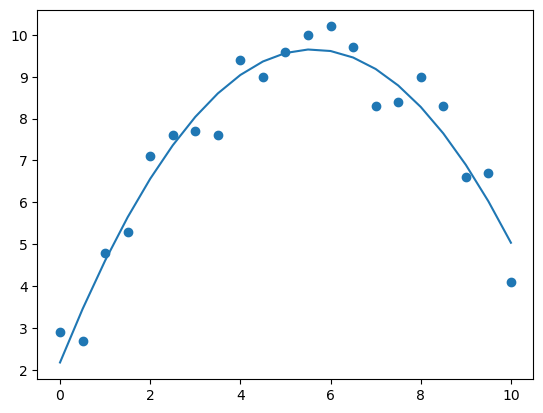

In [2]:
# 3.2
from matplotlib import pyplot as plt
from numpy.polynomial import Polynomial

ts = np.linspace(0, 10, 21)
ys = [2.9, 2.7, 4.8, 5.3, 7.1, 7.6, 7.7, 7.6, 9.4, 9, 9.6, 10, 10.2, 9.7, 8.3, 8.4, 9, 8.3, 6.6, 6.7, 4.1]
plt.scatter(ts, ys)
p = Polynomial(la.lstsq(np.vander(ts, N=3, increasing=True), ys)[0])
plt.plot(ts, p(ts))
p.coef

In [3]:
# 3.3
A = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [-1, 1, 0],
    [-1, 0, 1],
    [0, -1, 1],
])
b = np.array([1237, 1941, 2417, 711, 1177, 475])

x = la.solve(A.T @ A, A.T @ b, assume_a='pos')
r = b - A @ x

print(la.norm(r, ord=2) ** 2)

L = la.cholesky(A.T @ A, lower=True)
y = la.solve_triangular(L, A.T @ b, lower=True)
la.solve_triangular(L.T, y)



35.0


array([1236., 1943., 2416.])

In [4]:
# 3.4
A.T @ r
A_plus = la.inv((A.T @ A)) @ A.T
P = A @ A_plus
P

P_orthogonal = np.eye(6) - P
P_orthogonal
np.allclose(r, P_orthogonal @ b)
np.allclose(A @ x, P @ b)

True

In [5]:
# 3.5
la.norm(A, ord=2)
la.norm(A_plus, ord=2)
# A @ x, P @ b
# la.norm(A @ x, ord=2) / la.norm(b, ord=2)
# np.acos(_)


np.float64(1.0)

In [6]:
# 3.14
A_bottom = A[3:]
A_bottom[:, :2]
x = la.lstsq(A_bottom[:, :2], b[3:])[0]

b[3:] - A_bottom[:, :2] @ x

la.lstsq(A_bottom, b[3:])


(array([-629.33333333,   78.66666667,  550.66666667]),
 array([], dtype=float64),
 2,
 array([1.73205081e+00, 1.73205081e+00, 2.30949614e-17]))

In [7]:
# 3.15
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12],
])

la.svd(A)

(array([[-0.14087668,  0.82471435,  0.5472782 , -0.0220583 ],
        [-0.34394629,  0.42626394, -0.71326299,  0.43732815],
        [-0.54701591,  0.02781353, -0.21530863, -0.80848141],
        [-0.75008553, -0.37063688,  0.38129342,  0.39321156]]),
 array([2.54624074e+01, 1.29066168e+00, 1.84466178e-15]),
 array([[-0.50453315, -0.5745157 , -0.64449826],
        [-0.76077568, -0.05714052,  0.64649464],
        [-0.40824829,  0.81649658, -0.40824829]]))

In [8]:
# 3.16
U, D, V = la.svd(A_bottom)
V = V.T

x = np.dot(U[:, 0], b[3:]) / D[0] * V[:, 0] + np.dot(U[:, 1], b[3:]) / D[1] * V[:, 1]
x

array([-629.33333333,   78.66666667,  550.66666667])

In [9]:
A = np.array([
    [2, -1, 1],
    [1, 0, 1],
    [3, -1, 4],
])

_, D, _ = la.svd(A)
np.linalg.cond(A, p=2) # np.float64(17.492977713805708)
D.max() / D.min()
la.norm(A, ord=2)
D.max()



np.float64(5.722926953325028)

In [10]:
# 3.18
A = np.array([
    [.913, .659],
    [.78, .563],
    [.457, .33],
])

la.svd(A)

(array([[-0.7105806 , -0.26630886, -0.65127168],
        [-0.60706736, -0.23592311,  0.75882113],
        [-0.35573083,  0.93456935,  0.00597497]]),
 array([1.58460342e+00, 1.05619406e-04]),
 array([[-0.81082851, -0.5852838 ],
        [-0.5852838 ,  0.81082851]]))

In [11]:
# 3.19
A = np.array([
    [-1, 1, 0],
    [-1, 0, 1],
    [0, -1, 1],
])
U, d, V = la.svd(A)

d[:2] = 1 / d[:2]
d[2] = 0
A_plus = V.T @ np.diag(d) @ U.T
b = np.array([711, 1177, 475])
A_plus @ b


array([-629.33333333,   78.66666667,  550.66666667])

In [12]:
# 3.21
A = np.array([-2, -1, 3]).reshape(3, 1)
b = np.array([-1, 3, -2])
U, d, V = la.svd(A)
d[0] = 1/ d[0]
U, d, V

# solve by svd
D = np.zeros((len(V), len(U)))
np.fill_diagonal(D, d)
x1 = V.T @ D @ U.T @ b
x1 # -.5

# solve by lstsq
la.lstsq(A, b)

# exchange t and y
Y = b.reshape(3, 1)
T = A
la.lstsq(Y, T)

# total least squares
A_augment = np.hstack([A, b.reshape(-1, 1)])
_, _ , V = la.svd(A_augment)
V.T[-1]


array([-0.70710678, -0.70710678])

exercises

In [13]:
# 3.1
# (a)
A = np.array([
    [1, 10],
    [1, 15],
    [1, 20],
])
b = np.array([11.6, 11.85, 12.25])

# (b)
la.solve(A[:2], b[:2]) # [11.1 ,  0.05]
la.solve(A[1:], b[1:]) # [10.65,  0.08]
la.solve(A[[0, 2]], b[[0, 2]]) # [10.95 ,  0.065]

# (c)
la.solve(A.T @ A, A.T @ b) # [10.925,  0.065]

array([10.925,  0.065])

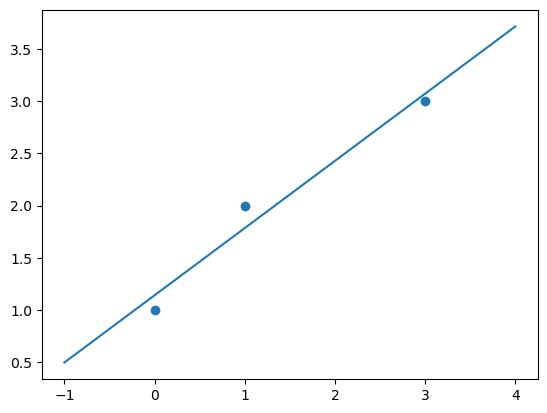

In [14]:
# 3.2
A = np.array([
    [0, 1],
    [1, 1],
    [3, 1],
])
b = np.array([1, 2, 3])

L = la.cholesky(A.T @ A, lower=True)
y = la.solve_triangular(L, A.T @ b, lower=True)
p = la.solve_triangular(L.T, y)
p # [0.64285714, 1.14285714]

la.solve(A.T @ A, A.T @ b) # [0.64285714, 1.14285714]

la.lstsq(A, b) # [0.64285714, 1.14285714]

x = np.linspace(-1, 4, 100)
y = p[0] * x + p[1]
plt.plot(x, y)
plt.scatter([0, 1, 3], [1, 2, 3])

In [15]:
# 3.3
A = np.array([
    [1, np.e],
    [2, np.exp(2)],
    [3, np.exp(3)],
])
b = [2, 3, 5]
la.solve(A.T @ A, A.T @ b)

array([1.59419483, 0.00876201])

In [16]:
# 3.4
A = np.array([
    [1, 0],
    [1, 1],
    [1, 1],
])

In [17]:
# 3.17
a = np.ones(4)
v = a - [-2, 0, 0, 0]

a - 2 * v * np.dot(v, a) / np.dot(v, v)


array([-2.,  0.,  0.,  0.])

In [18]:
# 3.19
a = np.array([2, 3, 4])

# (a)
A = np.eye(3)
A[2, 1] = -4/3
A @ a

# (b)
v = np.array([0, 8, 4]).reshape(3, 1)
H = np.eye(3) - 2 * v @ v.T / (v.T @ v)[0, 0]
H @ a

# (c)
c = 3 / 5
s = 4 / 5
G = np.eye(3)
G[1:, 1:] = np.array([
    [c, s],
    [-s, c],
])
G @ a

array([ 2.0000000e+00,  5.0000000e+00, -4.4408921e-16])

computer problems

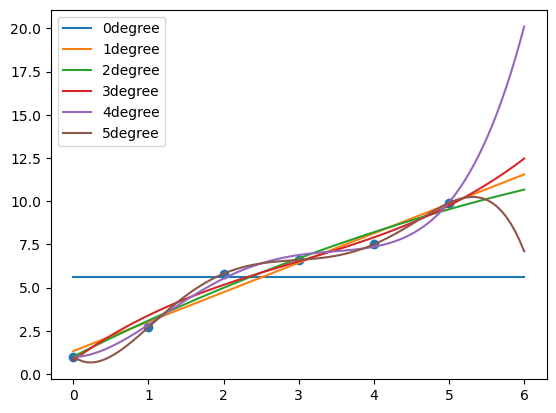

In [19]:
# 3.1
from numpy.polynomial import Polynomial

t = range(6)
b = [1, 2.7, 5.8, 6.6, 7.5, 9.9]
x = np.linspace(0, 6, 100)
plt.scatter(t, b)

for n in range(6):
    A = np.vander(range(6), N=n+1, increasing=True)
    p = Polynomial(la.lstsq(A, b)[0])
    y = p(x)
    plt.plot(x, y, label=f'{n}degree')

plt.legend()

In [20]:
# 3.2
A = np.vstack([
    np.eye(4),
    np.array([
        [1, -1, 0, 0],
        [1, 0, -1, 0],
        [1, 0, 0, -1],
        [0, 1, -1, 0],
        [0, 1, 0, -1],
        [0, 0, 1, -1],
    ])
])
b = [2.95, 1.74, -1.45, 1.32, 1.23, 4.45, 1.61, 3.21, .45, -2.75]

la.lstsq(A, b)

(array([ 2.96 ,  1.746, -1.46 ,  1.314]),
 np.float64(0.0036399999999999996),
 4,
 array([2.23606798, 2.23606798, 2.23606798, 1.        ]))

In [21]:
# 3.4
A = np.array([
    [.16, .1], [.17, .11], [2.02, 1.29],
])

b = np.array([.26, .28, 3.31])
np.linalg.cond(A)

x = la.lstsq(A, b)[0] # [1., 1.]

b_prime = np.array([.27, .25, 3.33])
x_prime = la.lstsq(A, b_prime)[0] # [ 7.00888731, -8.39566299]

def relative_ratio(delta, x):
    return la.norm(delta) / la.norm(x)

relative_ratio(x_prime - x, x)

np.linalg.cond(A) * relative_ratio(b_prime - b, b)

relative_ratio(A @ x, b)

1.0000000000000004

688.4294468693206
-2.635625483712101 0.14364618259889803 0.5514469631403583 3.2229403381058948 -0.43289427026445054


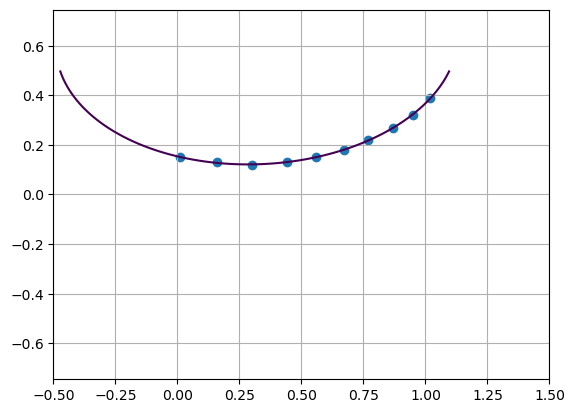

In [67]:
# 3.5
x = np.array([1.02, .95, .87, .77, .67, .56, .44, .3, .16, .01])
y = np.array([.39, .32, .27, .22, .18, .15, .13, .12, .13, .15])


def run(x, y):
    A = np.vstack([y*y, x*y, x, y, np.ones_like(x)]).T
    B = x*x

    print(np.linalg.cond(A))
    # print(la.svd(A))
    a, b, c, d, e = la.lstsq(A, B)[0]
    print(a, b, c, d, e)
    plot(a, b, c, d, e)
    


def plot(a, b, c, d, e):
    X, Y = np.meshgrid(np.linspace(-.5, 1.5, 100), np.linspace(-.5, .5, 100))

    Z = a * Y ** 2 + b * X * Y + c * X + d * Y + e - X * X
    plt.contour(X, Y, Z, levels=[0])
    plt.axis('equal')
    plt.grid(True)

    plt.scatter(x, y)

run(x, y)

659.2927404492048
-1.4051270147476131 -0.4067920792051253 0.6694871307461855 3.0155544743074616 -0.4416717136117003


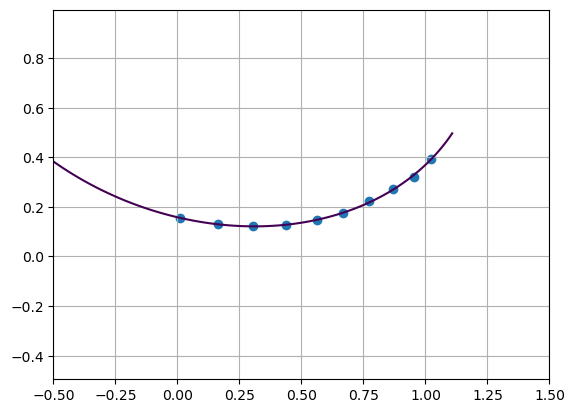

In [40]:
np.random.seed(0)
x_prime = x + np.random.uniform(-.005, .005, len(x))
y_prime = y + np.random.uniform(-.005, .005, len(x))

run(x_prime, y_prime)

[ 0.10441935  0.34013661  0.89178871  0.20248793 -0.17178939]
[ 0.41916488  0.87687127  0.52534501  0.75613853 -0.16744777]
[-2.63562548  0.14364618  0.55144696  3.22294034 -0.43289427]
[-2.63562548  0.14364618  0.55144696  3.22294034 -0.43289427]


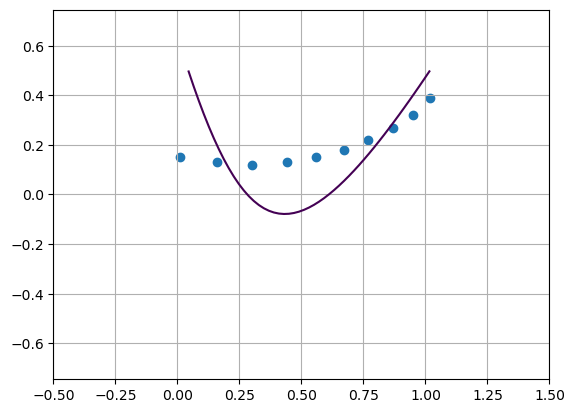

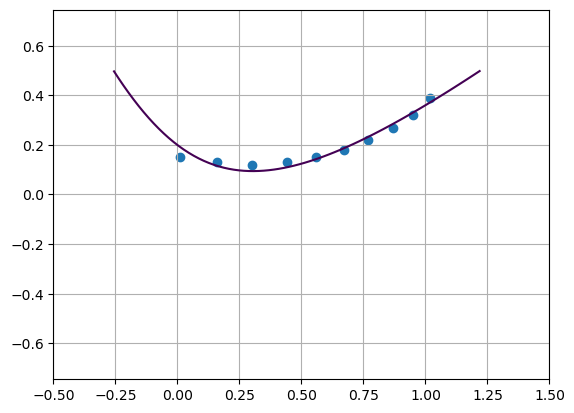

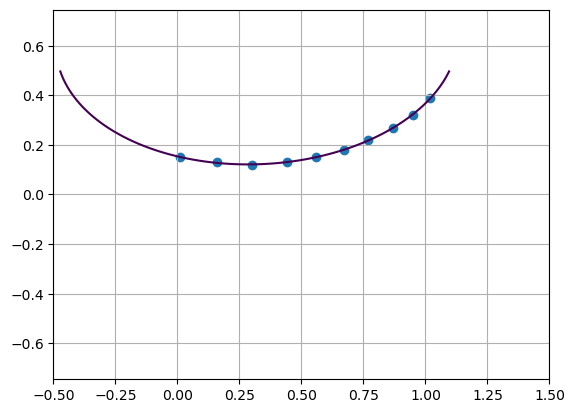

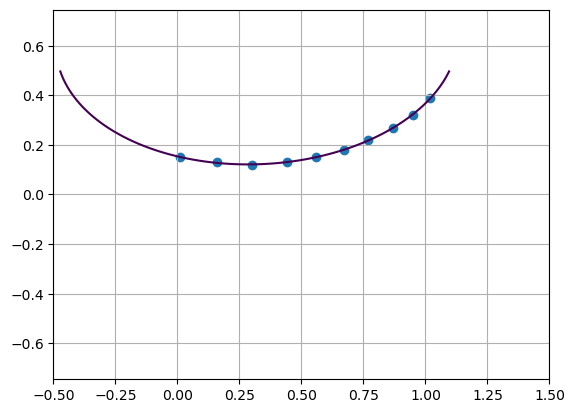

In [111]:
# def lstsq_rank_deficient(A, b, tol):
#     U, d, V = la.svd(A)
#     return sum([np.dot(U[:, index], b) / sigma * V[index] for index, sigma in enumerate(d[d > tol])])

def lstsq_rank_deficient(A, b, tol):
    return la.lstsq(A, b, cond=tol)[0]

def run_deficient(x, y, tol):
    A = np.vstack([y*y, x*y, x, y, np.ones_like(x)]).T
    B = x*x
    params = lstsq_rank_deficient(A, B, tol)
    print(params)
    plot(*params)


run_deficient(x, y, .1)
plt.figure()
run_deficient(x, y, .01)
plt.figure()
run_deficient(x, y, .001)
plt.figure()
run_deficient(x, y, .0001)


[-0.6216957  -0.84516169  0.73746448  3.0344145  -0.46160779]


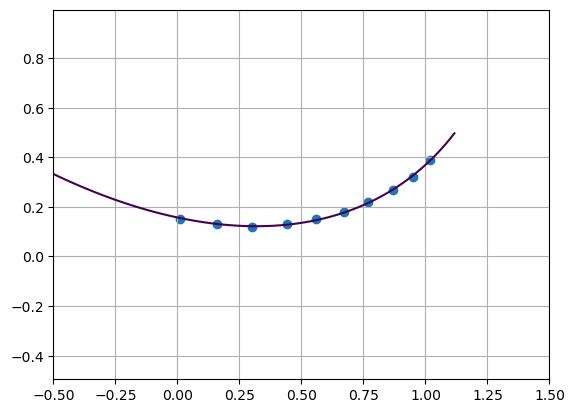

In [51]:
# run_deficient(x_prime, y_prime, .1)
# plt.figure()
run_deficient(x_prime, y_prime, .01)
# plt.figure()
# run_deficient(x_prime, y_prime, .001)
# plt.figure()
# run_deficient(x_prime, y_prime, .0001)

[-2.63562548  0.14364618  0.55144696  3.22294034 -0.43289427]


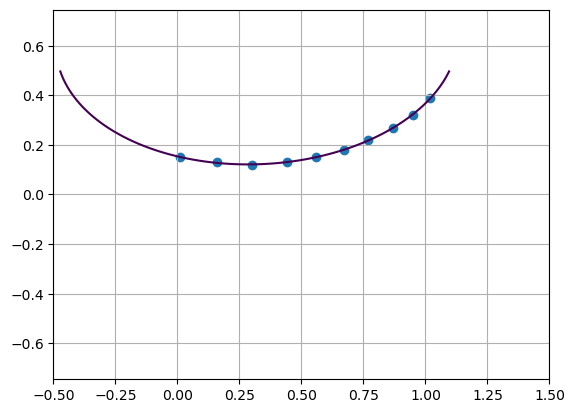

In [81]:
# (e)
def lstsq_rank_s(A, b, n):
    U, d, V = la.svd(A)
    return sum([np.dot(U[:, index], b) / sigma * V[index] for index, sigma in enumerate(d) if index < n])


def run_s(x, y, n):
    A = np.vstack([y*y, x*y, x, y, np.ones_like(x)]).T
    B = x*x
    params = lstsq_rank_s(A, B, n)
    print(params)
    plot(*params)

import time
from IPython.display import clear_output

for n in range(1, 6):
    clear_output(wait=True)
    run_s(x, y, n)
    plt.show()
    time.sleep(1)


[-3.26928571  0.45858913  0.50239702  3.24555074 -0.42249404]


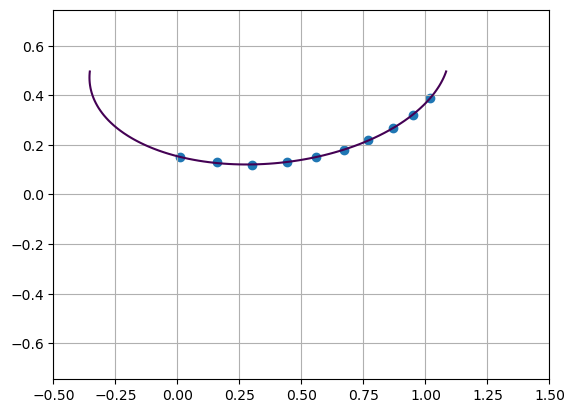

In [92]:
# (g) total least squares
def lstsq_total(C):
    U, d, V = la.svd(C)
    return (V[-1] / -V[-1][-1])[:-1]


def run_total(x, y):
    A = np.vstack([y*y, x*y, x, y, np.ones_like(x)]).T
    B = x*x
    C = np.hstack([A, B.reshape(-1, 1)])
    # print(C)
    params = lstsq_total(C)
    print(params)
    plot(*params)


run_total(x, y)


In [107]:
# 3.6
def pseudo_inverse(A, tol):
    U, d, V = la.svd(A)
    mask = d > tol
    print(d)
    d_inv = np.zeros_like(d)
    d_inv[mask] = 1 / d[mask]
    D_inv = np.zeros((U.shape[1], V.shape[0]))
    np.fill_diagonal(D_inv, d_inv)
    return V.T @ D_inv.T @ U.T


A = np.random.random((3, 3))
A_inv = la.inv(A)

A_plus = pseudo_inverse(A, .01)

print(np.allclose(A_inv, A_plus))


def hilbert_matrix(n):
    """生成 n x n 的 Hilbert 矩阵"""
    return np.array([[1/(i+j-1) for j in range(1, n+1)] for i in range(1, n+1)])


A = hilbert_matrix(4)
A_inv = la.inv(A)

A_plus = pseudo_inverse(A, .0001)

print(A_inv)
print(A_plus)


[2.00273435 0.30085025 0.0799189 ]
True
[1.50021428e+00 1.69141220e-01 6.73827361e-03 9.67023040e-05]
[[   16.  -120.   240.  -140.]
 [ -120.  1200. -2700.  1680.]
 [  240. -2700.  6480. -4200.]
 [ -140.  1680. -4200.  2800.]]
[[  7.18686854 -20.76557773   1.08199727  15.33760925]
 [-20.76557773  82.63659593  -9.82227021 -69.07613588]
 [  1.08199727  -9.82227021   3.09535869  11.09699074]
 [ 15.33760925 -69.07613588  11.09699074  62.06593312]]


In [145]:
# 3.8
m, n, eps = 21, 12, 10 ** (-10)
t = np.array([(i-1) / (m-1) for i in range(1, m+1)])
A = np.vander(t, increasing=True, N=n)
# print(A @ np.ones(n))
b = A @ np.ones(n)
b_perturb = A @ np.ones(n) + np.random.uniform(-1, 1, m) * eps

x = np.ones(n)



def print_result(b):
    x1 = la.solve(A.T @ A, A.T @ b, assume_a='pos')
    x2 = la.lstsq(A, b)[0]

    print(x1)
    print(x2)
    print(relative_ratio(x1 - x, x))
    print(relative_ratio(x2 - x, x))


print_result(b)
print_result(b_perturb)

[1.         1.00000183 0.99993325 1.00092524 0.99331958 1.02861273
 0.92252607 1.13623888 0.84470444 1.11072409 0.95511902 1.00789485]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
0.07296151067886926
2.744362359835611e-10
[1.         1.00000557 0.99978338 1.00318903 0.9756717  1.10956136
 0.68947729 1.56926479 0.32599008 1.49754297 0.79180499 1.03770885]
[1.         0.99999998 1.00000066 0.9999906  1.00006932 0.99969645
 1.00084219 0.9984796  1.00178156 0.99869317 1.00054514 0.99990132]
0.31354133428438896
0.0008319959818351028


In [150]:
# 3.9
A_augment = np.vstack([
    np.hstack([np.eye(m), A]),
    np.hstack([A.T, np.eye(n)*0]),
])
b_augment = np.hstack([b, np.zeros(n)])
b_perturb_augment = np.hstack([b_perturb, np.zeros(n)])


def run(A_augment, b_augment):
    x1 = la.solve(A_augment, b_augment, assume_a='sym')[-n:]
    print(relative_ratio(x1 - x, x))

run(A_augment, b_augment)
run(A_augment, b_perturb_augment)


0.0009372990818086835
0.00011116555472471378


c:\Users\chuny\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.27482e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [165]:
# 3.11
A = np.random.random((3, 3))
old = A.T @ A

Q, R = la.qr(A)
new  = R.T @ R

print(old)
print(new)

np.allclose(la.inv(old), la.inv(new))

[[0.81690106 0.78085388 0.69553405]
 [0.78085388 0.93968505 0.61412935]
 [0.69553405 0.61412935 0.62876219]]
[[0.81690106 0.78085388 0.69553405]
 [0.78085388 0.93968505 0.61412935]
 [0.69553405 0.61412935 0.62876219]]


True

In [214]:
# 3.12
def classical_gram_schmidt(A):
    A = A.copy().astype(float)
    m, n = A.shape
    R = np.zeros((n, n))
    for k in range(n):
        for j in range(k):
            R[j, k] = np.dot(A[:, j], A[:, k])
            A[:, k] -= R[j, k] * A[:, j]

        R[k, k] = la.norm(A[:, k])
        A[:, k] /=  R[k, k]
    return A, R


def modified_gram_schmidt(A):
    A = A.copy().astype(float)
    m, n = A.shape
    R = np.zeros((n, n))
    for k in range(n):
        R[k, k] = la.norm(A[:, k])
        A[:, k] /= R[k, k]
        for j in range(k+1, n):
            R[k, j] = np.dot(A[:, j], A[:, k])
            A[:, j] -= R[k, j] * A[:, k]        

    return A, R


A = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [-1, 1, 0],
    [-1, 0, 1],
    [0, -1., 1],
])
# print(la.qr(A))

print(1 / np.sqrt(3))
Q, R = classical_gram_schmidt(A)

np.allclose(Q @ R, A)


0.5773502691896258


True

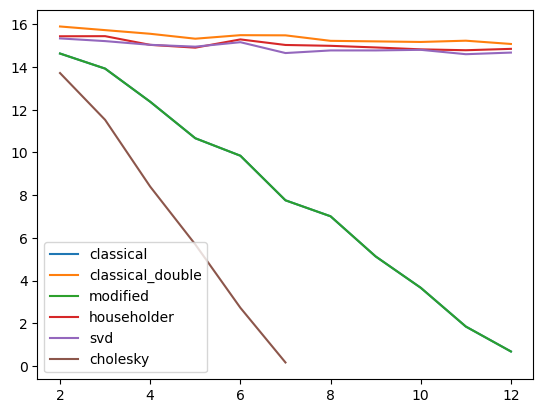

In [239]:
arr = []
for n in range(2, 13):
    A = hilbert_matrix(n)
    Q, R = classical_gram_schmidt(A)
    # print(Q.T @ Q)
    arr.append(-np.log10(la.norm(np.eye(n) - Q.T @ Q)))
plt.plot(range(2, 13), arr, label='classical')


print()
arr = []
for n in range(2, 13):
    A = hilbert_matrix(n)
    Q, R = classical_gram_schmidt(A)
    Q, R = classical_gram_schmidt(Q)
    arr.append(-np.log10(la.norm(np.eye(n) - Q.T @ Q)))
plt.plot(range(2, 13), arr, label='classical_double')


def modified_gram_schmidt(A):
    A = A.copy().astype(float)
    m, n = A.shape
    R = np.zeros((n, n)).astype(float)
    for k in range(n):
        R[k, k] = la.norm(A[:, k])
        A[:, k] /= R[k, k]
        for j in range(k+1, n):
            R[k, j] = np.dot(A[:, j], A[:, k])
            A[:, j] -= R[k, j] * A[:, k]        

    return A, R

print()
arr = []
for n in range(2, 13):
    A = hilbert_matrix(n)
    Q, R = modified_gram_schmidt(A)
    arr.append(-np.log10(la.norm(np.eye(n) - Q.T @ Q)))
plt.plot(range(2, 13), arr, label='modified')


print()
arr = []
for n in range(2, 13):
    A = hilbert_matrix(n)
    Q, R = la.qr(A)
    arr.append(-np.log10(la.norm(np.eye(n) - Q.T @ Q)))
plt.plot(range(2, 13), arr, label='householder')


print()
arr = []
for n in range(2, 13):
    A = hilbert_matrix(n)
    Q = la.svd(A)[0]
    arr.append(-np.log10(la.norm(np.eye(n) - Q.T @ Q)))
plt.plot(range(2, 13), arr, label='svd')



print()
arr = []
for n in range(2, 8):
    A = hilbert_matrix(n)
    L = la.cholesky(A.T @ A, lower=True)
    Q = A @ la.inv(L).T
    arr.append(-np.log10(la.norm(np.eye(n) - Q.T @ Q)))
plt.plot(range(2, 8), arr, label='cholesky')



plt.legend()